In [1]:
# Cell 1 - import wing-x for Light Jets
import pandas as pd
import numpy as np

# 1. SETUP & LOAD
METRO_PATH = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
print("🚀 Loading and processing Light Jet market audit...")
df = pd.read_parquet(METRO_PATH)

# 2. STANDARDIZE & FILTER
df['FlightDate_ET'] = pd.to_datetime(df['FlightDate_ET'])
df = df.rename(columns={'FromCluster': 'FromMetro', 'ToCluster': 'ToMetro'})

# Define the specific LJ models requested
lj_models = ['Phenom 300', 'Citation CJ', 'Hawker 400', 'Beechjet', 'Encore', 'Ultra']

# --- LJ SPECIFIC FILTER ---
mask = (
    (df['aircraft_segment'] == 'Light Jet') & 
    (df['aircraft_model'].isin(lj_models)) & 
    (df['FromMetro'] != 'OTHER_METRO') & 
    (df['ToMetro'] != 'OTHER_METRO') & 
    (df['FromMetro'] != df['ToMetro']) & # Kills Intra-Metro ghosts
    (df['Hours'] >= 1.5) # Adjusted threshold for Light Jets (e.g., 1.5 hrs)
)

# Create lj_lh as a clean, independent copy
lj_lh = df[mask].copy()

# Define corridor only for legitimate inter-metro pairs
lj_lh['corridor'] = lj_lh['FromMetro'] + " -> " + lj_lh['ToMetro']

# 3. WUP PRESENCE DEFINITION
wup_mask = ((lj_lh['Operator'].str.contains('Wheels Up', case=False, na=False)) | 
            (lj_lh['Operator'] == 'Mountain Aviation'))
lj_lh['is_wup'] = wup_mask

# 4. BI-DIRECTIONAL AGGREGATION
def make_pair_key(row):
    return " <-> ".join(sorted([row['FromMetro'], row['ToMetro']]))

lj_lh['pair_key'] = lj_lh.apply(make_pair_key, axis=1)

# Aggregation logic for audit
pair_analysis = lj_lh.groupby('pair_key').agg(
    total_pair_missions=('pair_key', 'size'),
    total_wup_missions=('is_wup', 'sum'),
    avg_hours_combined=('Hours', 'mean')
).reset_index()

def get_splits(group):
    counts = group['corridor'].value_counts()
    hrs = group.groupby('corridor')['Hours'].mean()
    wup = group.groupby('corridor')['is_wup'].sum()
    total = group.groupby('corridor').size()
    return pd.Series({
        'mission_split': " | ".join(counts.astype(str)),
        'hours_split': " | ".join([f"{h:.2f}" for h in hrs]),
        'share_split': " | ".join([f"{(w/t)*100:.1f}%" for w, t in zip(wup, total)])
    })

# 5. VALIDATION & OUTPUT
splits = lj_lh.groupby('pair_key').apply(get_splits).reset_index()
pair_analysis = pair_analysis.merge(splits, on='pair_key').sort_values('total_pair_missions', ascending=False)

# Validation print
intra_metro_count = lj_lh[lj_lh['FromMetro'] == lj_lh['ToMetro']].shape[0]
print(f"✅ LJ Market Audit Complete.")
print(f"1. Total Inter-Metro Missions: {len(lj_lh):,}")
print(f"2. Unique Directional Corridors: {lj_lh['corridor'].nunique()}")
print(f"3. Intra-Metro (Same City) Missions: {intra_metro_count}")

display(pair_analysis.head(10))

🚀 Loading and processing Light Jet market audit...
✅ LJ Market Audit Complete.
1. Total Inter-Metro Missions: 102,664
2. Unique Directional Corridors: 430
3. Intra-Metro (Same City) Missions: 0


/var/tmp/ipykernel_37026/3885266836.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  splits = lj_lh.groupby('pair_key').apply(get_splits).reset_index()


,pair_key,total_pair_missions,total_wup_missions,avg_hours_combined,mission_split,hours_split,share_split
124,Denver <-> LA Basin,4435,90,1.910210,2475 | 1960,1.96 | 1.84,1.8% | 2.3%
196,New York City <-> South Florida,3718,89,2.759651,1869 | 1849,2.84 | 2.68,2.3% | 2.5%
107,Dallas <-> Denver,3095,71,1.989965,1831 | 1264,2.06 | 1.88,2.3% | 2.2%
25,Bay Area <-> Denver,2601,48,2.007510,1463 | 1138,1.89 | 2.10,2.3% | 1.5%
89,Chicago <-> South Florida,2434,51,2.701342,1229 | 1205,2.61 | 2.79,1.8% | 2.4%
105,DMV <-> South Florida,2240,88,2.227723,1125 | 1115,2.30 | 2.15,4.2% | 3.6%
168,LA Basin <-> Seattle,2122,21,2.143583,1092 | 1030,2.15 | 2.14,0.9% | 1.1%
72,Charlotte <-> South Florida,2078,94,1.722891,1067 | 1011,1.74 | 1.70,4.8% | 4.3%
82,Chicago <-> New York City,2059,49,1.860733,1098 | 961,1.73 | 1.97,2.7% | 2.1%
19,Atlanta <-> South Florida,2001,72,1.657854,1195 | 806,1.64 | 1.67,4.2% | 3.2%


In [2]:
# -----------------------------------------------------------------------------------------
# CELL 2: DIRECTIONAL SEASONAL DISCOVERY — LIGHT JETS
# -----------------------------------------------------------------------------------------
from sklearn.cluster import KMeans

# 1. Build monthly corridor fingerprint
seasonal_counts = (lj_lh.groupby(["corridor", "month"]).size().unstack(fill_value=0))
seasonal_counts = seasonal_counts.reindex(columns=range(1, 13), fill_value=0)

# 2. Filter for statistical signal (Lowered to 20 for LJ)
MIN_MISSIONS = 20
annual_missions = seasonal_counts.sum(axis=1)
relevant_corridors = annual_missions > MIN_MISSIONS
seasonal_counts_relevant = seasonal_counts.loc[relevant_corridors].copy()

# 3. Normalize to monthly density (isolates the "shape")
monthly_density = seasonal_counts_relevant.div(seasonal_counts_relevant.sum(axis=1), axis=0)

# 4. Create seasonality index (1.00x = Average Month)
seasonality_index = monthly_density / (1 / 12)

# 5. K-Means clustering (Locked to 4 clusters per SMID logic)
km = KMeans(n_clusters=4, random_state=42, n_init=50)
cluster_ids = km.fit_predict(monthly_density)

# 6. Build audit/output dataframe
X_discovery = monthly_density.copy()
X_discovery["cluster_id"] = cluster_ids
X_discovery["annual_missions"] = annual_missions.loc[relevant_corridors] / 2

for m in range(1, 13):
    X_discovery[f"seasonality_index_m{m}"] = seasonality_index[m]

# 7. Display Heatmap 1: Monthly Density (%)
cluster_centers_density = (X_discovery.groupby("cluster_id")[list(range(1, 13))].mean().reindex(columns=range(1, 13)))
print(f"✅ Processed {len(X_discovery)} LJ corridors into 4 seasonal demand regimes.")
print("\n📈 MONTHLY DENSITY BY CLUSTER:")
display(cluster_centers_density.style.background_gradient(axis=1, cmap="YlOrRd").format("{:.1%}"))

# 8. Display Heatmap 2: Seasonality Index (x)
seasonality_cols = [f"seasonality_index_m{m}" for m in range(1, 13)]
cluster_centers_index = (X_discovery.groupby("cluster_id")[seasonality_cols].mean())
cluster_centers_index.columns = range(1, 13)
print("\n📈 SEASONALITY INDEX BY CLUSTER:")
display(cluster_centers_index.style.background_gradient(axis=1, cmap="YlOrRd").format("{:.2f}x"))

✅ Processed 360 LJ corridors into 4 seasonal demand regimes.

📈 MONTHLY DENSITY BY CLUSTER:


month,1,2,3,4,5,6,7,8,9,10,11,12
cluster_id,,,,,,,,,,,,
0,11.0%,10.4%,10.8%,10.2%,9.1%,5.2%,4.9%,4.3%,5.4%,7.7%,10.3%,10.6%
1,5.5%,5.2%,5.0%,5.8%,8.9%,10.2%,16.3%,11.4%,11.9%,8.2%,6.1%,5.6%
2,4.3%,4.7%,5.7%,7.5%,8.9%,11.2%,7.9%,10.6%,11.8%,12.5%,9.6%,5.3%
3,7.2%,7.4%,8.1%,9.2%,9.3%,7.9%,7.6%,8.2%,8.3%,10.1%,8.4%,8.5%



📈 SEASONALITY INDEX BY CLUSTER:


,1,2,3,4,5,6,7,8,9,10,11,12
cluster_id,,,,,,,,,,,,
0,1.32x,1.25x,1.29x,1.22x,1.09x,0.63x,0.59x,0.52x,0.65x,0.92x,1.24x,1.28x
1,0.66x,0.62x,0.59x,0.69x,1.07x,1.23x,1.95x,1.37x,1.42x,0.99x,0.73x,0.67x
2,0.52x,0.56x,0.68x,0.90x,1.07x,1.34x,0.95x,1.27x,1.42x,1.51x,1.15x,0.64x
3,0.86x,0.89x,0.97x,1.10x,1.11x,0.95x,0.91x,0.98x,1.00x,1.21x,1.01x,1.02x


In [3]:
# -----------------------------------------------------------------------------------------
# CELL 3.5: LABELED SEASONALITY AUDIT (SYNCED)
# -----------------------------------------------------------------------------------------

# 1. Re-define labels to ensure parity with Cell 4 Master Export
final_labels = {
    0: "winter-spring-peak",   
    1: "summer-peak",        
    2: "core-utilization", 
    3: "multi-peak-directional"
}

# 2. Calculate centers from X_discovery (Normalized Density)
labeled_centers = X_discovery.groupby("cluster_id")[list(range(1, 13))].mean()

# 3. Apply labels to the index for the Heatmap display
labeled_centers.index = [f"{i}: {final_labels.get(i, 'Unknown')}" for i in labeled_centers.index]

print("🎯 FINAL LJ ARCHETYPE HEATMAP (Monthly Density %):")
display(
    labeled_centers.style.background_gradient(axis=1, cmap="YlOrRd")
    .format("{:.1%}")
)

# 4. Toggle Logic Validation (May vs June)
# Index 5 = May, Index 6 = June
summer_jump = labeled_centers[6] - labeled_centers[5]
top_toggle = summer_jump.idxmax()

print(f"\n💡 The strongest June 'Toggle' candidate is: {top_toggle}")
print(f"📈 Momentum: +{summer_jump.max():.1%} absolute density increase MoM.")

🎯 FINAL LJ ARCHETYPE HEATMAP (Monthly Density %):


month,1,2,3,4,5,6,7,8,9,10,11,12
0: winter-spring-peak,11.0%,10.4%,10.8%,10.2%,9.1%,5.2%,4.9%,4.3%,5.4%,7.7%,10.3%,10.6%
1: summer-peak,5.5%,5.2%,5.0%,5.8%,8.9%,10.2%,16.3%,11.4%,11.9%,8.2%,6.1%,5.6%
2: core-utilization,4.3%,4.7%,5.7%,7.5%,8.9%,11.2%,7.9%,10.6%,11.8%,12.5%,9.6%,5.3%
3: multi-peak-directional,7.2%,7.4%,8.1%,9.2%,9.3%,7.9%,7.6%,8.2%,8.3%,10.1%,8.4%,8.5%



💡 The strongest June 'Toggle' candidate is: 2: core-utilization
📈 Momentum: +2.3% absolute density increase MoM.


In [4]:
# -----------------------------------------------------------------------------------------
# FINAL VALIDATION: LJ UNIVERSE & VOLUME DISTRIBUTION
# -----------------------------------------------------------------------------------------

# 1. Sync labels specifically for LJ Archetypes (Verified in Cell 3.5)
final_labels_lj = {
    0: "winter-spring-peak",   
    1: "summer-peak",        
    2: "core-utilization", 
    3: "multi-peak-directional"
}

# 2. Metadata & Volume Calculations
total_corridors = len(X_discovery)
total_flights = X_discovery['annual_missions'].sum()

# Grouping by mapped labels for volume analysis
stats = X_discovery.groupby('cluster_id').agg({'annual_missions': ['count', 'sum']})
stats.index = stats.index.map(final_labels_lj)
stats.columns = ['corridor_count', 'flight_volume']
stats['volume_pct'] = (stats['flight_volume'] / total_flights) * 100

# 3. Intra-Metro Check
intra_metro_issues = [c for c in X_discovery.index if c.split(' -> ')[0] == c.split(' -> ')[1]]

# 4. Validation Output
print("📊 --- LIGHT JET CLUSTER UNIVERSE SUMMARY ---")
print(f"📌 Filtering Criteria Applied:")
print(f"   - Segment      : Light Jet (Select Models)")
print(f"   - Min Leg Time : >= 1.5 Hours")
print(f"   - Relevance    : > {MIN_MISSIONS} missions total (2-yr)")
print(f"   - Logic        : Inter-Metro Only (No Same-City)")

print(f"\n✅ Total Inter-Metro Corridors : {total_corridors}")
print(f"✅ Total Annual Flight Volume  : {total_flights:,.0f} (Annualized /2)")

print("\n📍 LJ ARCHETYPE BREAKDOWN (Volume & Count):")
print(f"{'Archetype':<25} | {'Corridors':<10} | {'Flights':<12} | {'Volume %'}")
print("-" * 65)
for label, row in stats.sort_values('flight_volume', ascending=False).iterrows():
    print(f"{label:<25} | {int(row['corridor_count']):<10} | {int(row['flight_volume']):<12,} | {row['volume_pct']:.1f}%")

print("\n🛡️ --- SAFETY CHECKS ---")
if not intra_metro_issues:
    print(f"✅ Final Validation Passed: 0 intra-metro corridors found.")
else:
    print(f"❌ Final Validation Failed: Found {len(intra_metro_issues)} intra-metro records!")

📊 --- LIGHT JET CLUSTER UNIVERSE SUMMARY ---
📌 Filtering Criteria Applied:
   - Segment      : Light Jet (Select Models)
   - Min Leg Time : >= 1.5 Hours
   - Relevance    : > 20 missions total (2-yr)
   - Logic        : Inter-Metro Only (No Same-City)

✅ Total Inter-Metro Corridors : 360
✅ Total Annual Flight Volume  : 51,049 (Annualized /2)

📍 LJ ARCHETYPE BREAKDOWN (Volume & Count):
Archetype                 | Corridors  | Flights      | Volume %
-----------------------------------------------------------------
multi-peak-directional    | 147        | 22,416       | 43.9%
winter-spring-peak        | 88         | 17,122       | 33.5%
core-utilization          | 76         | 6,399        | 12.5%
summer-peak               | 49         | 5,111        | 10.0%

🛡️ --- SAFETY CHECKS ---
✅ Final Validation Passed: 0 intra-metro corridors found.


In [5]:
# -----------------------------------------------------------------------------------------
# CELL 5: CHART-READY EXPORT — CORRIDOR MONTHLY DENSITY % + CLUSTER ID
# -----------------------------------------------------------------------------------------

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# 1. Pull corridor, monthly density columns, cluster_id, annual_missions
chart_df = X_discovery[list(range(1, 13)) + ["cluster_id", "annual_missions"]].copy()
chart_df = chart_df.reset_index().rename(columns={"corridor": "corridor"})

# 2. Convert density fractions → percentages, round to 2dp
for m in range(1, 13):
    chart_df[m] = (chart_df[m] * 100).round(2)

# 3. Rename month columns to names
chart_df = chart_df.rename(columns=MONTH_NAMES)

# 4. Add cluster label
chart_df["cluster_label"] = chart_df["cluster_id"].map(final_labels_lj)

# 5. Sort: cluster_id first, then annual_missions descending
chart_df = chart_df.sort_values(["cluster_id", "annual_missions"], ascending=[True, False]).reset_index(drop=True)

# 6. Final column order
month_cols = list(MONTH_NAMES.values())
chart_df = chart_df[["corridor"] + month_cols + ["cluster_id", "cluster_label", "annual_missions"]]

# 7. Export to CSV
OUT_PATH = "lj_kmeans_corridor_monthly_pct.csv"
chart_df.to_csv(OUT_PATH, index=False)

print(f"✅ Chart dataset ready: {len(chart_df)} corridors × {len(chart_df.columns)} columns")
print(f"📁 Exported to: {OUT_PATH}")
print(f"\n🔍 Shape validation:")
print(f"   - Month columns sum per row (sample): {chart_df[month_cols].sum(axis=1).head(3).round(1).tolist()} (expect ~100.0)")
print(f"   - Unique cluster_ids: {sorted(chart_df['cluster_id'].unique().tolist())}")

display(chart_df.head(10))

✅ Chart dataset ready: 360 corridors × 16 columns
📁 Exported to: lj_kmeans_corridor_monthly_pct.csv

🔍 Shape validation:
   - Month columns sum per row (sample): [100.0, 100.0, 100.0] (expect ~100.0)
   - Unique cluster_ids: [0, 1, 2, 3]


month,corridor,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,cluster_id,cluster_label,annual_missions
0,South Florida -> New York City,10.97,11.72,12.04,10.43,10.38,5.94,2.94,3.69,3.69,7.01,10.75,10.43,0,winter-spring-peak,934.5
1,New York City -> South Florida,10.44,9.79,11.63,9.46,7.84,5.52,2.97,4.06,4.54,9.25,11.25,13.25,0,winter-spring-peak,924.5
2,Chicago -> South Florida,9.60,11.96,12.21,7.97,6.59,4.07,3.74,3.25,3.17,9.03,12.45,15.95,0,winter-spring-peak,614.5
3,South Florida -> Chicago,9.71,10.46,13.28,10.71,10.62,4.98,4.40,3.07,4.32,5.73,10.04,12.70,0,winter-spring-peak,602.5
4,South Florida -> Atlanta,12.38,10.29,10.13,10.46,6.61,5.19,4.02,3.93,3.51,9.46,11.05,12.97,0,winter-spring-peak,597.5
5,South Florida -> DMV,9.51,10.22,11.47,12.98,9.16,4.44,4.80,3.56,4.27,7.56,9.69,12.36,0,winter-spring-peak,562.5
6,DMV -> South Florida,11.39,10.22,10.49,9.78,8.34,5.92,4.22,4.48,4.13,7.53,10.40,13.09,0,winter-spring-peak,557.5
7,Charlotte -> South Florida,9.65,8.15,10.50,9.75,8.43,7.12,5.72,4.59,6.09,8.62,9.00,12.37,0,winter-spring-peak,533.5
8,South Florida -> Charlotte,8.11,10.19,11.97,7.12,7.81,7.91,5.93,4.85,5.04,7.81,10.29,12.96,0,winter-spring-peak,505.5
9,Atlanta -> South Florida,11.29,8.56,10.17,9.93,7.32,6.20,6.82,6.82,5.58,8.19,9.31,9.80,0,winter-spring-peak,403.0


In [6]:
len(chart_df["corridor"].unique())

360

In [7]:
chart_df[chart_df["cluster_id"]==3].shape

(147, 16)

In [8]:
# -----------------------------------------------------------------------------------------
# CELL 6: LONG FORMAT — corridor | month | percentage | cluster_label
# -----------------------------------------------------------------------------------------

month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

long_df = chart_df.melt(
    id_vars=["corridor", "cluster_id", "cluster_label"],
    value_vars=month_cols,
    var_name="month",
    value_name="density_pct"
)

# Preserve calendar month order
long_df["month"] = pd.Categorical(long_df["month"], categories=month_cols, ordered=True)
long_df = long_df.sort_values(["cluster_id", "corridor", "month"]).reset_index(drop=True)

# Drop cluster_id if you only need the label
long_df = long_df[["corridor", "month", "density_pct", "cluster_label"]]

# Export
LONG_OUT = "lj_kmeans_corridor_long.csv"
long_df.to_csv(LONG_OUT, index=False)

print(f"✅ Long format ready: {len(long_df):,} rows × {len(long_df.columns)} columns")
print(f"   ({len(chart_df)} corridors × 12 months = {len(chart_df)*12} rows)")
print(f"📁 Exported to: {LONG_OUT}")

display(long_df.head(24))

✅ Long format ready: 4,320 rows × 4 columns
   (360 corridors × 12 months = 4320 rows)
📁 Exported to: lj_kmeans_corridor_long.csv


,corridor,month,density_pct,cluster_label
0,Atlanta -> Dallas,Jan,9.34,winter-spring-peak
1,Atlanta -> Dallas,Feb,7.45,winter-spring-peak
2,Atlanta -> Dallas,Mar,9.20,winter-spring-peak
3,Atlanta -> Dallas,Apr,12.26,winter-spring-peak
4,Atlanta -> Dallas,May,7.74,winter-spring-peak
5,Atlanta -> Dallas,Jun,6.42,winter-spring-peak
6,Atlanta -> Dallas,Jul,4.53,winter-spring-peak
7,Atlanta -> Dallas,Aug,4.67,winter-spring-peak
8,Atlanta -> Dallas,Sep,9.20,winter-spring-peak
9,Atlanta -> Dallas,Oct,8.76,winter-spring-peak


In [9]:
# -----------------------------------------------------------------------------------------
# CELL 7: INTENSITY SLAB ANALYSIS — corridor | month | density_pct | cluster_label | slab | intensity
# -----------------------------------------------------------------------------------------

bins   = [0, 4, 6, 9, 12, 15, float("inf")]
labels = ["< 4%", "4%-6%", "6%-9%", "9%-12%", "12%-15%", "> 15%"]
intensity_map = {"< 4%": 0, "4%-6%": 1, "6%-9%": 2, "9%-12%": 3, "12%-15%": 4, "> 15%": 5}

slab_df = long_df.copy()
slab_df["slab"]      = pd.cut(slab_df["density_pct"], bins=bins, labels=labels, right=False)
slab_df["intensity"] = slab_df["slab"].map(intensity_map)

# Final column order
slab_df = slab_df[["corridor", "month", "density_pct", "cluster_label", "slab", "intensity"]]

# Export
SLAB_OUT = "lj_kmeans_intensity_slab.csv"
slab_df.to_csv(SLAB_OUT, index=False)

print(f"✅ Intensity slab dataset ready: {len(slab_df):,} rows")
print(f"📁 Exported to: {SLAB_OUT}")
display(slab_df.head(24))

✅ Intensity slab dataset ready: 4,320 rows
📁 Exported to: lj_kmeans_intensity_slab.csv


,corridor,month,density_pct,cluster_label,slab,intensity
0,Atlanta -> Dallas,Jan,9.34,winter-spring-peak,9%-12%,3
1,Atlanta -> Dallas,Feb,7.45,winter-spring-peak,6%-9%,2
2,Atlanta -> Dallas,Mar,9.20,winter-spring-peak,9%-12%,3
3,Atlanta -> Dallas,Apr,12.26,winter-spring-peak,12%-15%,4
4,Atlanta -> Dallas,May,7.74,winter-spring-peak,6%-9%,2
5,Atlanta -> Dallas,Jun,6.42,winter-spring-peak,6%-9%,2
6,Atlanta -> Dallas,Jul,4.53,winter-spring-peak,4%-6%,1
7,Atlanta -> Dallas,Aug,4.67,winter-spring-peak,4%-6%,1
8,Atlanta -> Dallas,Sep,9.20,winter-spring-peak,9%-12%,3
9,Atlanta -> Dallas,Oct,8.76,winter-spring-peak,6%-9%,2


In [10]:
slab_df["corridor"].unique()

array(['Atlanta -> Dallas', 'Atlanta -> Houston',
       'Atlanta -> South Florida', 'Atlanta -> St. Louis',
       'Bay Area -> Houston', 'Charlotte -> Atlanta',
       'Charlotte -> Nashville', 'Charlotte -> North Florida',
       'Charlotte -> South Florida', 'Chicago -> Houston',
       'Chicago -> South Florida', 'DMV -> Atlanta', 'DMV -> Nashville',
       'DMV -> North Florida', 'DMV -> South Florida',
       'Dallas -> Phoenix Valley', 'Dallas -> San Antonio',
       'Dallas -> South Florida', 'Denver -> North Florida',
       'Denver -> Phoenix Valley', 'Denver -> South Florida',
       'Detroit -> Phoenix Valley', 'Detroit -> South Florida',
       'Houston -> Dallas', 'Houston -> LA Basin',
       'Houston -> Phoenix Valley', 'Houston -> San Antonio',
       'Houston -> South Florida', 'LA Basin -> Atlanta',
       'LA Basin -> Bay Area', 'LA Basin -> Houston',
       'LA Basin -> North Florida', 'LA Basin -> South Florida',
       'Minneapolis -> Phoenix Valley', 'Minneapol

In [11]:
# -----------------------------------------------------------------------------------------
# CELL 8: ADD DOMINANT AIRCRAFT MODEL PER CORRIDOR
# -----------------------------------------------------------------------------------------

# Most common aircraft_model per corridor (across all missions in lj_lh)
dominant_model = (
    lj_lh.groupby("corridor")["aircraft_model"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"aircraft_model": "dominant_model"})
)

# All unique models per corridor (comma-separated)
all_models = (
    lj_lh.groupby("corridor")["aircraft_model"]
    .agg(lambda x: ", ".join(sorted(x.unique())))
    .reset_index()
    .rename(columns={"aircraft_model": "all_models"})
)

# Merge into slab_df
slab_df_v2 = (
    slab_df
    .merge(dominant_model, on="corridor", how="left")
    .merge(all_models, on="corridor", how="left")
)

slab_df_v2 = slab_df_v2[["corridor", "month", "density_pct", "cluster_label", "slab", "intensity", "dominant_model", "all_models"]]

# Export
SLAB_V2_OUT = "lj_kmeans_intensity_slab_v2.csv"
slab_df_v2.to_csv(SLAB_V2_OUT, index=False)

print(f"✅ Updated dataset ready: {len(slab_df_v2):,} rows")
print(f"📁 Exported to: {SLAB_V2_OUT}")
display(slab_df_v2.head(12))

✅ Updated dataset ready: 4,320 rows
📁 Exported to: lj_kmeans_intensity_slab_v2.csv


,corridor,month,density_pct,cluster_label,slab,intensity,dominant_model,all_models
0,Atlanta -> Dallas,Jan,9.34,winter-spring-peak,9%-12%,3,Phenom 300,Phenom 300
1,Atlanta -> Dallas,Feb,7.45,winter-spring-peak,6%-9%,2,Phenom 300,Phenom 300
2,Atlanta -> Dallas,Mar,9.20,winter-spring-peak,9%-12%,3,Phenom 300,Phenom 300
3,Atlanta -> Dallas,Apr,12.26,winter-spring-peak,12%-15%,4,Phenom 300,Phenom 300
4,Atlanta -> Dallas,May,7.74,winter-spring-peak,6%-9%,2,Phenom 300,Phenom 300
5,Atlanta -> Dallas,Jun,6.42,winter-spring-peak,6%-9%,2,Phenom 300,Phenom 300
6,Atlanta -> Dallas,Jul,4.53,winter-spring-peak,4%-6%,1,Phenom 300,Phenom 300
7,Atlanta -> Dallas,Aug,4.67,winter-spring-peak,4%-6%,1,Phenom 300,Phenom 300
8,Atlanta -> Dallas,Sep,9.20,winter-spring-peak,9%-12%,3,Phenom 300,Phenom 300
9,Atlanta -> Dallas,Oct,8.76,winter-spring-peak,6%-9%,2,Phenom 300,Phenom 300


In [12]:
# -----------------------------------------------------------------------------------------
# CELL 9: ENRICHED DATASET — ALL SIGNALS IN ONE TABLE
# -----------------------------------------------------------------------------------------

MONTH_NUM = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
             "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}

# --- A. Corridor-level lookups from lj_lh ---
corridor_stats = lj_lh.groupby("corridor").agg(
    avg_hours=("Hours", "mean"),
    wup_share_pct=("is_wup", lambda x: round(x.mean() * 100, 2)),
    model_count=("aircraft_model", "nunique")
).reset_index()

# Dominant model share %
dom_model_lookup = (lj_lh.groupby("corridor")["aircraft_model"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index().rename(columns={"aircraft_model": "dominant_model"}))
dom_model_counts = lj_lh.groupby(["corridor","aircraft_model"]).size().reset_index(name="model_missions")
total_counts = lj_lh.groupby("corridor").size().reset_index(name="total_missions")
dom_model_counts = (dom_model_counts
    .merge(dom_model_lookup, on="corridor")
    .merge(total_counts, on="corridor"))
dom_model_counts = dom_model_counts[dom_model_counts["aircraft_model"] == dom_model_counts["dominant_model"]]
dom_model_counts["dominant_model_share_pct"] = (dom_model_counts["model_missions"] / dom_model_counts["total_missions"] * 100).round(1)
dom_share_lookup = dom_model_counts[["corridor", "dominant_model_share_pct"]]

# --- B. Annual missions from X_discovery ---
annual_lookup = X_discovery[["annual_missions"]].reset_index()

# --- C. Mission count per corridor-month (raw 2yr count / 2 annualized) ---
mission_counts_long = (
    seasonal_counts_relevant.reset_index()
    .melt(id_vars="corridor", var_name="month_num", value_name="mission_count")
)
mission_counts_long["mission_count"] = (mission_counts_long["mission_count"] / 2).round(0).astype(int)

# --- D. Seasonality index per corridor-month from X_discovery ---
si_long = (
    X_discovery[[f"seasonality_index_m{m}" for m in range(1, 13)]]
    .reset_index()
    .melt(id_vars="corridor", var_name="si_col", value_name="seasonality_index")
)
si_long["month_num"] = si_long["si_col"].map({f"seasonality_index_m{m}": m for m in range(1, 13)})
si_long = si_long[["corridor", "month_num", "seasonality_index"]]

# --- E. Build enriched_df ---
enriched_df = slab_df_v2.copy()
enriched_df["month_num"] = enriched_df["month"].map(MONTH_NUM)
enriched_df["from_metro"] = enriched_df["corridor"].str.split(" -> ").str[0]
enriched_df["to_metro"]   = enriched_df["corridor"].str.split(" -> ").str[1]

enriched_df = (enriched_df
    .merge(mission_counts_long, on=["corridor", "month_num"], how="left")
    .merge(si_long,             on=["corridor", "month_num"], how="left")
    .merge(annual_lookup,       on="corridor",                how="left")
    .merge(corridor_stats,      on="corridor",                how="left")
    .merge(dom_share_lookup,    on="corridor",                how="left")
)

# Derived flags
enriched_df["above_avg"]     = enriched_df["density_pct"] > round(100 / 12, 4)
peak_idx                     = enriched_df.groupby("corridor")["density_pct"].idxmax()
enriched_df["is_peak_month"] = False
enriched_df.loc[peak_idx, "is_peak_month"] = True

# Final column order
enriched_df = enriched_df[[
    "corridor", "from_metro", "to_metro",
    "month", "mission_count", "density_pct", "seasonality_index", "above_avg", "is_peak_month",
    "slab", "intensity", "cluster_label",
    "annual_missions", "wup_share_pct", "avg_hours",
    "dominant_model", "dominant_model_share_pct", "model_count", "all_models"
]].sort_values(["cluster_label", "corridor", "month"]).reset_index(drop=True)

# Export
ENRICHED_OUT = "lj_kmeans_enriched.csv"
enriched_df.to_csv(ENRICHED_OUT, index=False)

print(f"✅ Enriched dataset ready: {len(enriched_df):,} rows × {len(enriched_df.columns)} columns")
print(f"📁 Exported to: {ENRICHED_OUT}")
print(f"\n🔍 Validation:")
print(f"   - is_peak_month == True : {enriched_df['is_peak_month'].sum()} (expect 360)")
print(f"   - above_avg == True     : {enriched_df['above_avg'].sum()} (expect ~2160)")
print(f"   - Null seasonality_index: {enriched_df['seasonality_index'].isna().sum()}")
display(enriched_df.head(12))

✅ Enriched dataset ready: 4,320 rows × 19 columns
📁 Exported to: lj_kmeans_enriched.csv

🔍 Validation:
   - is_peak_month == True : 360 (expect 360)
   - above_avg == True     : 2046 (expect ~2160)
   - Null seasonality_index: 0


,corridor,from_metro,to_metro,month,mission_count,density_pct,seasonality_index,above_avg,is_peak_month,slab,intensity,cluster_label,annual_missions,wup_share_pct,avg_hours,dominant_model,dominant_model_share_pct,model_count,all_models
0,Atlanta -> Boston,Atlanta,Boston,Jan,4,3.85,0.461538,False,False,< 4%,0,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
1,Atlanta -> Boston,Atlanta,Boston,Feb,2,2.14,0.256410,False,False,< 4%,0,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
2,Atlanta -> Boston,Atlanta,Boston,Mar,4,3.42,0.410256,False,False,< 4%,0,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
3,Atlanta -> Boston,Atlanta,Boston,Apr,10,8.55,1.025641,True,False,6%-9%,2,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
4,Atlanta -> Boston,Atlanta,Boston,May,10,8.12,0.974359,False,False,6%-9%,2,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
5,Atlanta -> Boston,Atlanta,Boston,Jun,18,14.96,1.794872,True,True,12%-15%,4,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
6,Atlanta -> Boston,Atlanta,Boston,Jul,14,11.97,1.435897,True,False,9%-12%,3,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
7,Atlanta -> Boston,Atlanta,Boston,Aug,15,12.82,1.538462,True,False,12%-15%,4,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
8,Atlanta -> Boston,Atlanta,Boston,Sep,12,10.68,1.282051,True,False,9%-12%,3,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300
9,Atlanta -> Boston,Atlanta,Boston,Oct,12,10.68,1.282051,True,False,9%-12%,3,core-utilization,117.0,3.85,2.145869,Phenom 300,100.0,1,Phenom 300


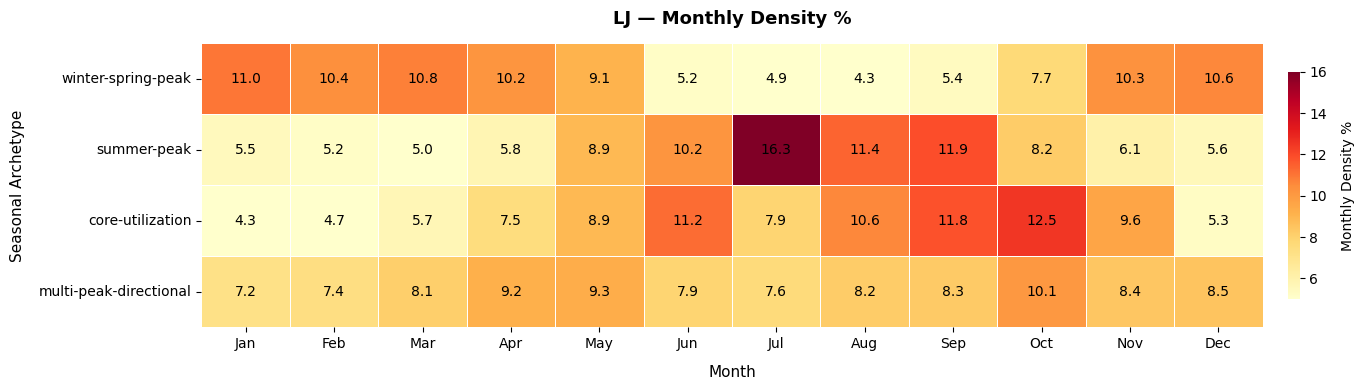

✅ Saved → lj_monthly_density_heatmap.png


In [13]:
# -----------------------------------------------------------------------------------------
# LJ MONTHLY DENSITY HEATMAP — saved as image
# Dependencies: Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
# Row order matches cluster_id 0→1→2→3
ARCHETYPE_ORDER = ["winter-spring-peak","summer-peak","core-utilization","multi-peak-directional"]

final_labels_lj = {0:"winter-spring-peak", 1:"summer-peak",
                   2:"core-utilization",   3:"multi-peak-directional"}

# Build cluster-center monthly density pivot
density_df = X_discovery[list(range(1,13)) + ["cluster_id"]].copy()
density_df["cluster_label"] = density_df["cluster_id"].map(final_labels_lj)
density_df = density_df.rename(columns={m: mn for m, mn in enumerate(MONTHS, 1)})

pivot = (density_df.groupby("cluster_label")[MONTHS]
                   .mean()
                   .mul(100)
                   .round(1)
                   .reindex(index=ARCHETYPE_ORDER))

# Toggle insight
summer_jump = pivot["Jun"] - pivot["May"]
top_toggle  = summer_jump.idxmax()

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", vmin=5, vmax=16,
    annot=True, fmt=".1f",
    annot_kws={"size": 10, "color": "black"},
    linewidths=0.6, linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.set_title(
    f"LJ — Monthly Density %",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Seasonal Archetype", fontsize=11, labelpad=10)
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)

ax.collections[0].colorbar.set_label("Monthly Density %", fontsize=10, labelpad=10)

plt.tight_layout()
OUT = "lj_monthly_density_heatmap.png"
plt.savefig(OUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {OUT}")

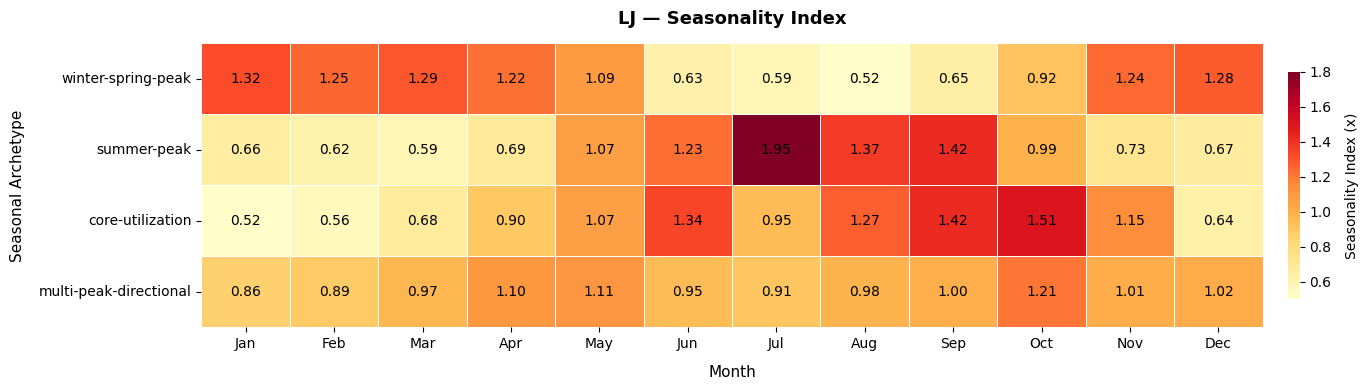

✅ Saved → lj_seasonality_index_heatmap.png


In [14]:
# -----------------------------------------------------------------------------------------
# LJ SEASONALITY INDEX HEATMAP — saved as image
# Dependencies: Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
# Row order matches cluster_id 0→1→2→3
ARCHETYPE_ORDER = ["winter-spring-peak","summer-peak","core-utilization","multi-peak-directional"]

final_labels_lj = {0:"winter-spring-peak", 1:"summer-peak",
                   2:"core-utilization",   3:"multi-peak-directional"}

# Build cluster-center seasonality index pivot
si_col_map = {f"seasonality_index_m{m}": mn for m, mn in enumerate(MONTHS, 1)}
si_df = X_discovery[[f"seasonality_index_m{m}" for m in range(1,13)] + ["cluster_id"]].copy()
si_df["cluster_label"] = si_df["cluster_id"].map(final_labels_lj)
si_df = si_df.rename(columns=si_col_map)

pivot = (si_df.groupby("cluster_label")[MONTHS]
              .mean()
              .round(2)
              .reindex(index=ARCHETYPE_ORDER))

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", vmin=0.5, vmax=1.8,
    annot=True, fmt=".2f",
    annot_kws={"size": 10, "color": "black"},
    linewidths=0.6, linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.set_title("LJ — Seasonality Index",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Seasonal Archetype", fontsize=11, labelpad=10)
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)

ax.collections[0].colorbar.set_label("Seasonality Index (x)", fontsize=10, labelpad=10)

plt.tight_layout()
OUT = "lj_seasonality_index_heatmap.png"
plt.savefig(OUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {OUT}")

In [15]:
# -----------------------------------------------------------------------------------------
# LJ SEASONALITY INDEX SLAB DATASET
# corridor | month | seasonality_index | cluster_label | slab | intensity
# Dependencies: Cell 2 (X_discovery)
# -----------------------------------------------------------------------------------------

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

final_labels_lj = {0:"winter-spring-peak", 1:"summer-peak",
                   2:"core-utilization",   3:"multi-peak-directional"}

# Build long format: corridor × month × seasonality_index
si_col_map = {f"seasonality_index_m{m}": mn for m, mn in MONTH_NAMES.items()}
si_df = X_discovery[[f"seasonality_index_m{m}" for m in range(1,13)] + ["cluster_id"]].copy()
si_df["cluster_label"] = si_df["cluster_id"].map(final_labels_lj)
si_df = si_df.rename(columns=si_col_map).reset_index()

si_long = si_df.melt(
    id_vars=["corridor", "cluster_label"],
    value_vars=list(MONTH_NAMES.values()),
    var_name="month", value_name="seasonality_index"
)
si_long["seasonality_index"] = si_long["seasonality_index"].round(2)

# Slab + intensity (centered on 1.0x baseline)
bins   = [0, 0.5, 0.7, 1.0, 1.3, 1.6, float("inf")]
labels = ["< 0.5x", "0.5x-0.7x", "0.7x-1.0x",
          "1.0x-1.3x", "1.3x-1.6x", ">= 1.6x"]
intensity_map = {"< 0.5x":0, "0.5x-0.7x":1, "0.7x-1.0x":2,
                 "1.0x-1.3x":3, "1.3x-1.6x":4, ">= 1.6x":5}

si_long["slab"]      = pd.cut(si_long["seasonality_index"], bins=bins, labels=labels, right=False)
si_long["intensity"] = si_long["slab"].map(intensity_map)

# Calendar month order & sort
month_order = list(MONTH_NAMES.values())
si_long["month"] = pd.Categorical(si_long["month"], categories=month_order, ordered=True)
si_long = (si_long[["corridor", "month", "seasonality_index", "cluster_label", "slab", "intensity"]]
           .sort_values(["cluster_label", "corridor", "month"]).reset_index(drop=True))

si_long.to_csv("lj_kmeans_seasonality_index_slab.csv", index=False)

print(f"✅ LJ Seasonality index slab dataset ready: {len(si_long):,} rows × {len(si_long.columns)} columns")
print(f"📁 Exported to: lj_kmeans_seasonality_index_slab.csv")
print(f"\n📊 Slab distribution:")
print(si_long["slab"].value_counts().sort_index().to_string())
display(si_long.head(24))

✅ LJ Seasonality index slab dataset ready: 4,320 rows × 6 columns
📁 Exported to: lj_kmeans_seasonality_index_slab.csv

📊 Slab distribution:
slab
< 0.5x        509
0.5x-0.7x     566
0.7x-1.0x    1152
1.0x-1.3x    1153
1.3x-1.6x     574
>= 1.6x       366


,corridor,month,seasonality_index,cluster_label,slab,intensity
0,Atlanta -> Boston,Jan,0.46,core-utilization,< 0.5x,0
1,Atlanta -> Boston,Feb,0.26,core-utilization,< 0.5x,0
2,Atlanta -> Boston,Mar,0.41,core-utilization,< 0.5x,0
3,Atlanta -> Boston,Apr,1.03,core-utilization,1.0x-1.3x,3
4,Atlanta -> Boston,May,0.97,core-utilization,0.7x-1.0x,2
5,Atlanta -> Boston,Jun,1.79,core-utilization,>= 1.6x,5
6,Atlanta -> Boston,Jul,1.44,core-utilization,1.3x-1.6x,4
7,Atlanta -> Boston,Aug,1.54,core-utilization,1.3x-1.6x,4
8,Atlanta -> Boston,Sep,1.28,core-utilization,1.0x-1.3x,3
9,Atlanta -> Boston,Oct,1.28,core-utilization,1.0x-1.3x,3


In [16]:
# -----------------------------------------------------------------------------------------
# COMBINE LJ + SMID SEASONALITY INDEX SLAB DATASETS
# Reads: lj_kmeans_seasonality_index_slab.csv + smid_kmeans_seasonality_index_slab.csv
# Output: lj_smid_seasonality_index_slab_combined.csv
# -----------------------------------------------------------------------------------------
import pandas as pd

lj_si   = pd.read_csv("lj_kmeans_seasonality_index_slab.csv")
smid_si = pd.read_csv("smid_kmeans_seasonality_index_slab.csv")

lj_si["AircraftType"]   = "Light Jet"
smid_si["AircraftType"] = "Super Mid"

combined_si = pd.concat([lj_si, smid_si], ignore_index=True)

# Final column order
combined_si = combined_si[[
    "AircraftType", "corridor", "month",
    "seasonality_index", "cluster_label", "slab", "intensity"
]]

OUT = "lj_smid_seasonality_index_slab_combined.csv"
combined_si.to_csv(OUT, index=False)

print(f"✅ Combined SI slab dataset ready: {len(combined_si):,} rows × {len(combined_si.columns)} columns")
print(f"   - Light Jet rows : {(combined_si['AircraftType']=='Light Jet').sum():,}")
print(f"   - Super Mid rows : {(combined_si['AircraftType']=='Super Mid').sum():,}")
print(f"📁 Exported to: {OUT}")
display(combined_si.head(12))

✅ Combined SI slab dataset ready: 7,788 rows × 7 columns
   - Light Jet rows : 4,320
   - Super Mid rows : 3,468
📁 Exported to: lj_smid_seasonality_index_slab_combined.csv


,AircraftType,corridor,month,seasonality_index,cluster_label,slab,intensity
0,Light Jet,Atlanta -> Boston,Jan,0.46,core-utilization,< 0.5x,0
1,Light Jet,Atlanta -> Boston,Feb,0.26,core-utilization,< 0.5x,0
2,Light Jet,Atlanta -> Boston,Mar,0.41,core-utilization,< 0.5x,0
3,Light Jet,Atlanta -> Boston,Apr,1.03,core-utilization,1.0x-1.3x,3
4,Light Jet,Atlanta -> Boston,May,0.97,core-utilization,0.7x-1.0x,2
5,Light Jet,Atlanta -> Boston,Jun,1.79,core-utilization,>= 1.6x,5
6,Light Jet,Atlanta -> Boston,Jul,1.44,core-utilization,1.3x-1.6x,4
7,Light Jet,Atlanta -> Boston,Aug,1.54,core-utilization,1.3x-1.6x,4
8,Light Jet,Atlanta -> Boston,Sep,1.28,core-utilization,1.0x-1.3x,3
9,Light Jet,Atlanta -> Boston,Oct,1.28,core-utilization,1.0x-1.3x,3


In [17]:
# -----------------------------------------------------------------------------------------
# CELL 10: CORRIDOR SEASONAL DATASET
# corridor | month | density_pct | seasonality_index | cluster_label
# Reads:  lj_kmeans_intensity_slab.csv
# Output: lj_corridor_seasonal_dataset.csv
# Formula: seasonality_index = density_pct * 12 / 100  (1.0x = flat baseline = 8.33%)
# -----------------------------------------------------------------------------------------
import pandas as pd

df = pd.read_csv("lj_kmeans_intensity_slab.csv")

df["seasonality_index"] = (df["density_pct"] * 12 / 100).round(4)

out = df[["corridor", "month", "density_pct", "seasonality_index", "cluster_label"]]

out.to_csv("lj_corridor_seasonal_dataset.csv", index=False)
print(f"✅ Corridor seasonal dataset ready: {len(out):,} rows × {len(out.columns)} columns")
print(f"📁 Exported to: lj_corridor_seasonal_dataset.csv")
print(f"🔍 Spot-check (Atlanta->Dallas Jan): density_pct=9.34 → seasonality_index={9.34*12/100:.4f} (expect 1.1208)")
display(out.head(12))

✅ Corridor seasonal dataset ready: 4,320 rows × 5 columns
📁 Exported to: lj_corridor_seasonal_dataset.csv
🔍 Spot-check (Atlanta->Dallas Jan): density_pct=9.34 → seasonality_index=1.1208 (expect 1.1208)


,corridor,month,density_pct,seasonality_index,cluster_label
0,Atlanta -> Dallas,Jan,9.34,1.1208,winter-spring-peak
1,Atlanta -> Dallas,Feb,7.45,0.8940,winter-spring-peak
2,Atlanta -> Dallas,Mar,9.20,1.1040,winter-spring-peak
3,Atlanta -> Dallas,Apr,12.26,1.4712,winter-spring-peak
4,Atlanta -> Dallas,May,7.74,0.9288,winter-spring-peak
5,Atlanta -> Dallas,Jun,6.42,0.7704,winter-spring-peak
6,Atlanta -> Dallas,Jul,4.53,0.5436,winter-spring-peak
7,Atlanta -> Dallas,Aug,4.67,0.5604,winter-spring-peak
8,Atlanta -> Dallas,Sep,9.20,1.1040,winter-spring-peak
9,Atlanta -> Dallas,Oct,8.76,1.0512,winter-spring-peak


📊 CLUSTER CATEGORIZATION SUMMARY:


,corridors,avg_density_pct,avg_seasonality_index
cluster_label,,,
winter-spring-peak,88,8.3331,1.0
summer-peak,49,8.3334,1.0
core-utilization,76,8.3333,1.0
multi-peak-directional,147,8.3332,1.0


📐 CROSS-VERIFICATION DELTA (new dataset avg − heatmap center):
   All cells should be 0.0000 — any non-zero means a discrepancy


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
cluster_label,,,,,,,,,,,,
winter-spring-peak,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
summer-peak,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
core-utilization,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
multi-peak-directional,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


✅ PASS — Max absolute delta: 0.0000% (dataset is consistent with heatmap)


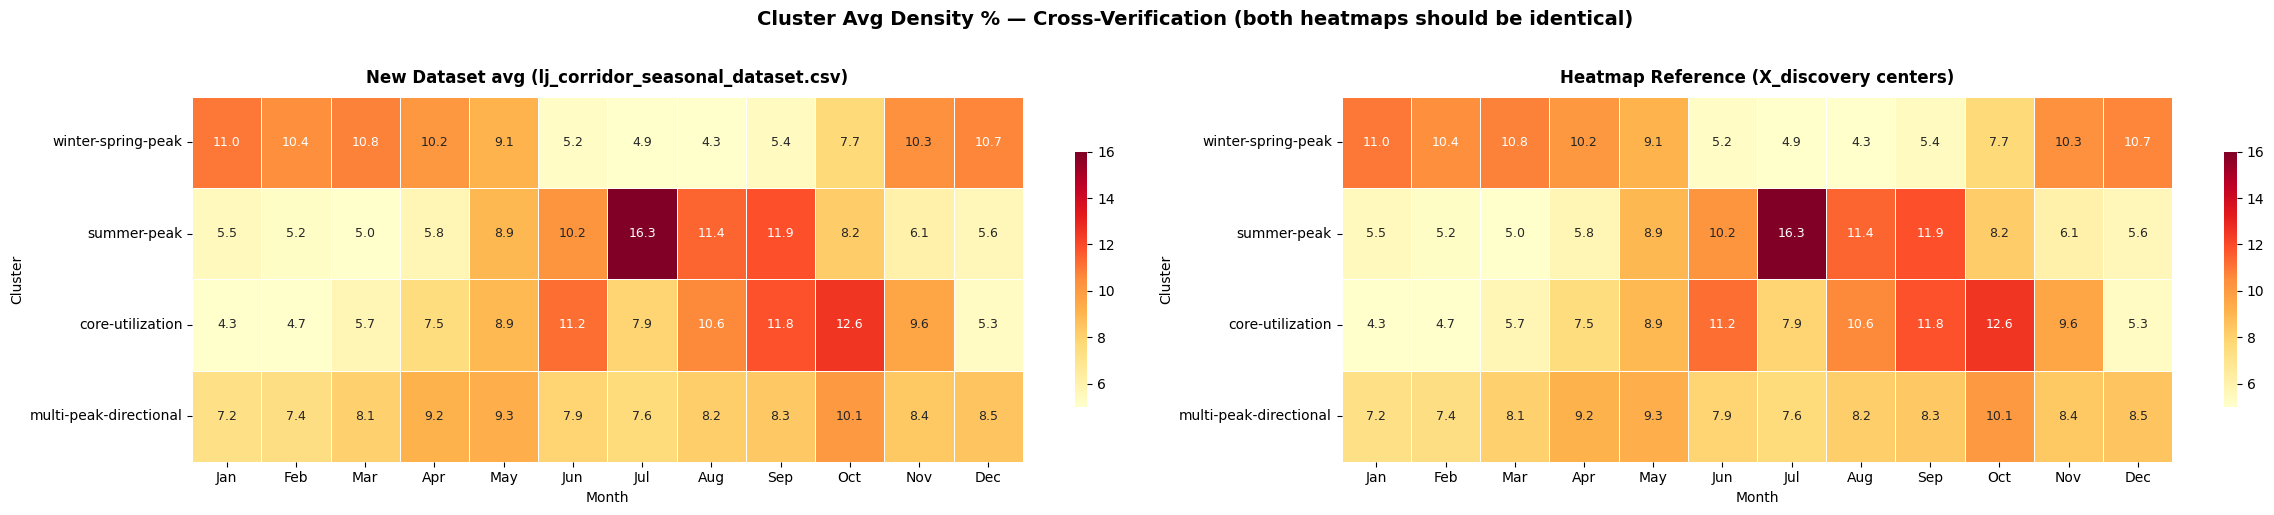

✅ Saved → lj_cluster_crossverify_heatmap.png


In [18]:
# -----------------------------------------------------------------------------------------
# CELL 11: CLUSTER CATEGORIZATION & HEATMAP CROSS-VERIFICATION
# Reads:  lj_corridor_seasonal_dataset.csv
# Cross-checks cluster-avg density_pct against heatmap cluster centers (X_discovery)
# A zero delta table means the new dataset is 100% consistent with the heatmap
# -----------------------------------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ARCHETYPE_ORDER = ["winter-spring-peak","summer-peak","core-utilization","multi-peak-directional"]

out = pd.read_csv("lj_corridor_seasonal_dataset.csv")

# --- 1. Categorization summary per cluster ---
print("📊 CLUSTER CATEGORIZATION SUMMARY:")
cat_summary = (
    out.groupby("cluster_label").agg(
        corridors=("corridor", "nunique"),
        avg_density_pct=("density_pct", "mean"),
        avg_seasonality_index=("seasonality_index", "mean")
    ).reindex(ARCHETYPE_ORDER)
)
display(cat_summary.round(4))

# --- 2. Cluster-avg monthly density pivot (from new dataset) ---
pivot_new = (
    out.groupby(["cluster_label", "month"])["density_pct"]
       .mean().reset_index()
       .pivot(index="cluster_label", columns="month", values="density_pct")
       .reindex(index=ARCHETYPE_ORDER, columns=MONTHS)
       .round(2)
)

# --- 3. Ground-truth cluster centers from X_discovery (same source as heatmap) ---
_lbl = {0:"winter-spring-peak",1:"summer-peak",2:"core-utilization",3:"multi-peak-directional"}
_d   = X_discovery[list(range(1,13)) + ["cluster_id"]].copy()
_d["cluster_label"] = _d["cluster_id"].map(_lbl)
_d = _d.rename(columns={m: mn for m, mn in enumerate(MONTHS, 1)})
pivot_ref = (_d.groupby("cluster_label")[MONTHS].mean().mul(100).round(2).reindex(index=ARCHETYPE_ORDER))

# --- 4. Delta table ---
delta = (pivot_new - pivot_ref).round(4)
print("📐 CROSS-VERIFICATION DELTA (new dataset avg − heatmap center):")
print("   All cells should be 0.0000 — any non-zero means a discrepancy")
display(delta.style.background_gradient(cmap="RdYlGn", axis=None, vmin=-0.5, vmax=0.5).format("{:.4f}"))
max_delta = delta.abs().max().max()
if max_delta < 0.01:
    print(f"✅ PASS — Max absolute delta: {max_delta:.4f}% (dataset is consistent with heatmap)")
else:
    print(f"❌ FAIL — Max absolute delta: {max_delta:.4f}% (investigate!)")

# --- 5. Side-by-side heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(24, 5))
for ax, pivot, title in zip(
    axes,
    [pivot_new, pivot_ref],
    ["New Dataset avg (lj_corridor_seasonal_dataset.csv)", "Heatmap Reference (X_discovery centers)"]
):
    sns.heatmap(
        pivot, ax=ax, cmap="YlOrRd", vmin=5, vmax=16,
        annot=True, fmt=".1f", annot_kws={"size": 9},
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.7}
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Month"); ax.set_ylabel("Cluster")
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Cluster Avg Density % — Cross-Verification (both heatmaps should be identical)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("lj_cluster_crossverify_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → lj_cluster_crossverify_heatmap.png")

# TOP 12

In [19]:
# -----------------------------------------------------------------------------------------
# CELL 12: COMPREHENSIVE DATASET
# cluster_label | corridor | month | density_pct | seasonality_index | slab | intensity
# Merges lj_corridor_seasonal_dataset.csv + lj_kmeans_intensity_slab.csv
# Output: lj_comprehensive.csv
# -----------------------------------------------------------------------------------------
import pandas as pd

MONTH_ORDER     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ARCHETYPE_ORDER = ['winter-spring-peak','summer-peak','core-utilization','multi-peak-directional']

base = pd.read_csv('lj_corridor_seasonal_dataset.csv')
slab = pd.read_csv('lj_kmeans_intensity_slab.csv')[['corridor','month','slab','intensity']]

comp = base.merge(slab, on=['corridor','month'], how='left')
comp['month']         = pd.Categorical(comp['month'],         categories=MONTH_ORDER,     ordered=True)
comp['cluster_label'] = pd.Categorical(comp['cluster_label'], categories=ARCHETYPE_ORDER, ordered=True)
comp = (comp[['cluster_label','corridor','month','density_pct','seasonality_index','slab','intensity']]
            .sort_values(['cluster_label','corridor','month'])
            .reset_index(drop=True))

comp.to_csv('lj_comprehensive.csv', index=False)
print(f'Done: {len(comp):,} rows x {len(comp.columns)} columns -> lj_comprehensive.csv')
display(comp.head(12))

Done: 4,320 rows x 7 columns -> lj_comprehensive.csv


,cluster_label,corridor,month,density_pct,seasonality_index,slab,intensity
0,winter-spring-peak,Atlanta -> Dallas,Jan,9.34,1.1208,9%-12%,3
1,winter-spring-peak,Atlanta -> Dallas,Feb,7.45,0.8940,6%-9%,2
2,winter-spring-peak,Atlanta -> Dallas,Mar,9.20,1.1040,9%-12%,3
3,winter-spring-peak,Atlanta -> Dallas,Apr,12.26,1.4712,12%-15%,4
4,winter-spring-peak,Atlanta -> Dallas,May,7.74,0.9288,6%-9%,2
5,winter-spring-peak,Atlanta -> Dallas,Jun,6.42,0.7704,6%-9%,2
6,winter-spring-peak,Atlanta -> Dallas,Jul,4.53,0.5436,4%-6%,1
7,winter-spring-peak,Atlanta -> Dallas,Aug,4.67,0.5604,4%-6%,1
8,winter-spring-peak,Atlanta -> Dallas,Sep,9.20,1.1040,9%-12%,3
9,winter-spring-peak,Atlanta -> Dallas,Oct,8.76,1.0512,6%-9%,2


Done: 48 rows x 10 columns -> lj_top12_per_archetype.csv


,cluster_label,rank,corridor,peak_month,peak_density_pct,avg_density_pct,avg_seasonality_idx,months_above_avg,peak_slab,peak_intensity
0,winter-spring-peak,1,Phoenix Valley -> South Florida,Jan,32.61,8.33,0.9999,4,> 15%,5
1,winter-spring-peak,2,LA Basin -> North Florida,Feb,32.00,8.33,1.0000,3,> 15%,5
2,winter-spring-peak,3,LA Basin -> South Florida,Apr,25.93,8.33,0.9999,5,> 15%,5
3,winter-spring-peak,4,Nashville -> St. Louis,Nov,25.93,8.33,0.9998,5,> 15%,5
4,winter-spring-peak,5,San Antonio -> Dallas,Jun,21.05,8.33,0.9999,5,> 15%,5
5,winter-spring-peak,6,Dallas -> San Antonio,Nov,20.97,8.33,1.0000,4,> 15%,5
6,winter-spring-peak,7,Charlotte -> Atlanta,Dec,20.59,8.33,0.9998,5,> 15%,5
7,winter-spring-peak,8,Bay Area -> Houston,Nov,20.00,8.33,0.9998,6,> 15%,5
8,winter-spring-peak,9,North Florida -> Atlanta,May,20.00,8.33,1.0000,4,> 15%,5
9,winter-spring-peak,10,LA Basin -> Bay Area,Mar,19.75,8.33,1.0000,5,> 15%,5


/var/tmp/ipykernel_37026/596547368.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


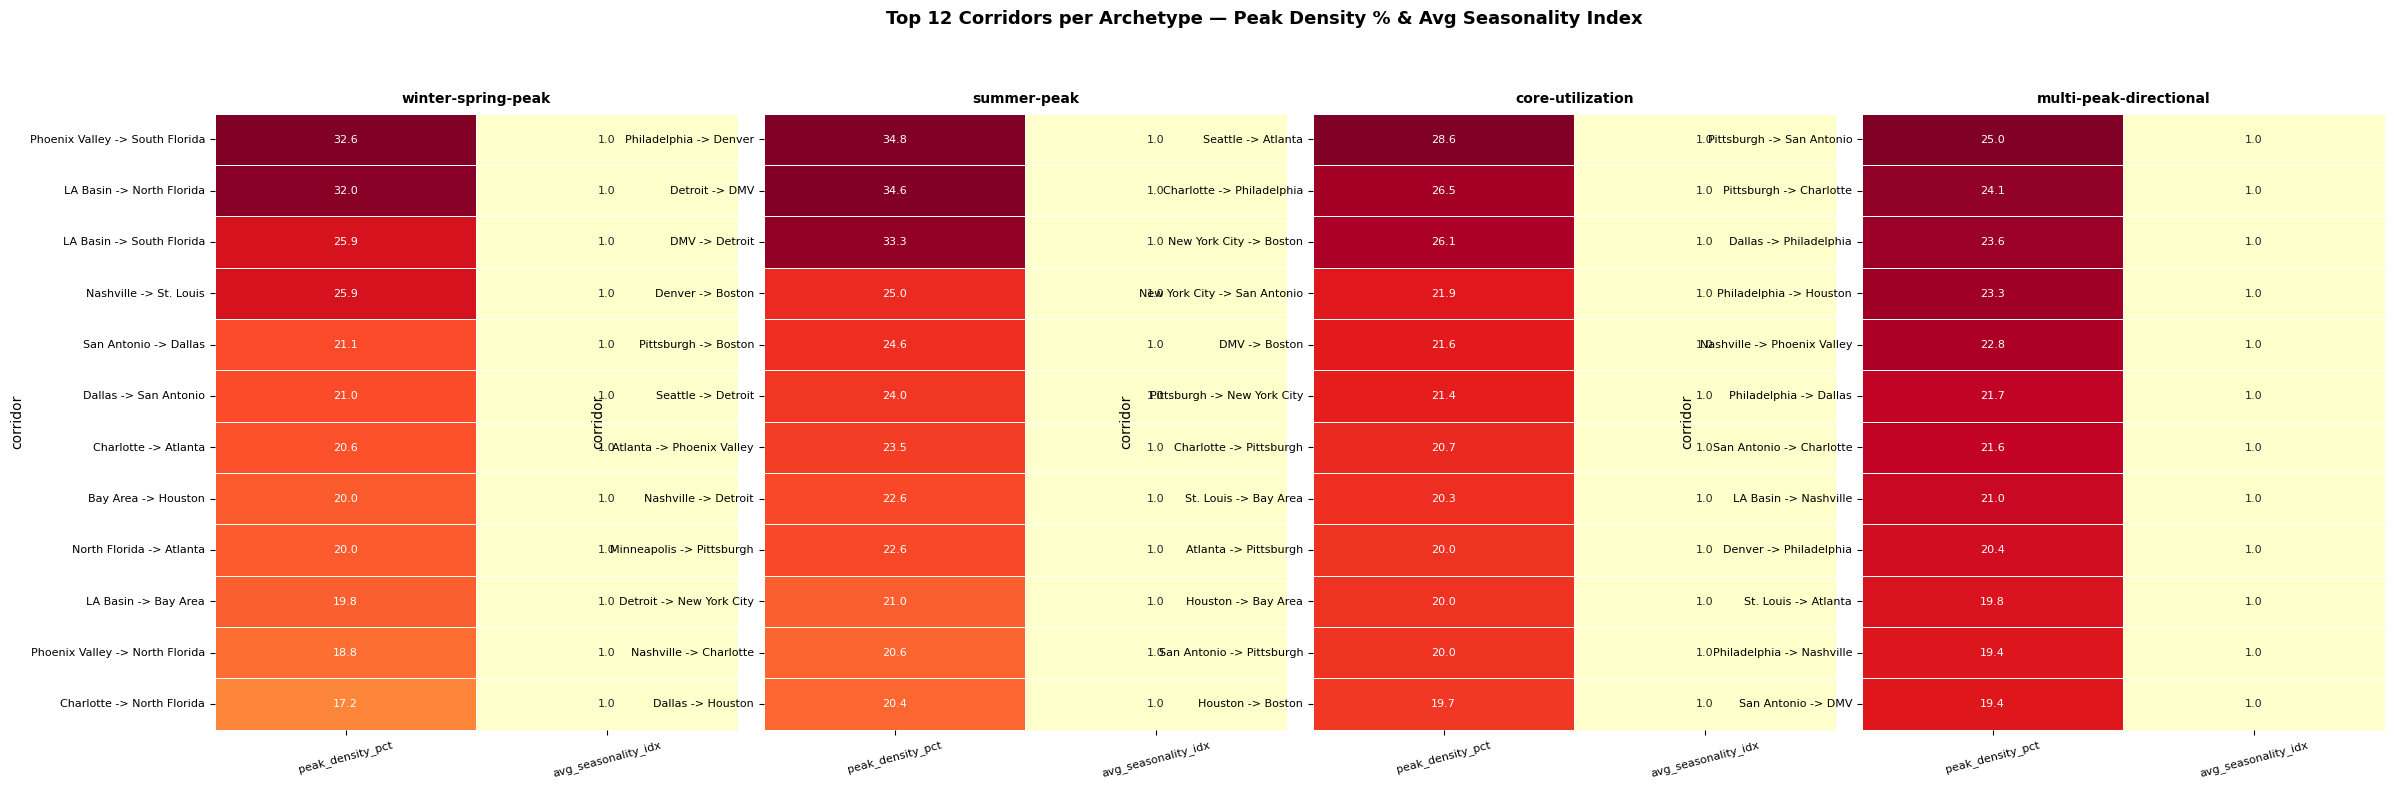

Saved -> lj_top12_heatmap.png


In [20]:
# -----------------------------------------------------------------------------------------
# CELL 13: TOP 12 CORRIDORS PER ARCHETYPE
# Ranked by peak_density_pct within each cluster_label
# Reads: lj_comprehensive.csv
# Output: lj_top12_per_archetype.csv
# -----------------------------------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MONTH_ORDER     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ARCHETYPE_ORDER = ['winter-spring-peak','summer-peak','core-utilization','multi-peak-directional']

comp = pd.read_csv('lj_comprehensive.csv')
comp['month']         = pd.Categorical(comp['month'],         categories=MONTH_ORDER,     ordered=True)
comp['cluster_label'] = pd.Categorical(comp['cluster_label'], categories=ARCHETYPE_ORDER, ordered=True)

# Corridor-level aggregation
def peak_month(g):
    return g.loc[g['density_pct'].idxmax(), 'month']

def peak_slab(g):
    return g.loc[g['intensity'].idxmax(), 'slab']

agg = (comp.groupby(['cluster_label','corridor'], observed=True)
           .apply(lambda g: pd.Series({
               'peak_density_pct'   : g['density_pct'].max(),
               'peak_month'         : peak_month(g),
               'avg_density_pct'    : g['density_pct'].mean().round(2),
               'avg_seasonality_idx': g['seasonality_index'].mean().round(4),
               'months_above_avg'   : int((g['density_pct'] > 100/12).sum()),
               'peak_intensity'     : int(g['intensity'].max()),
               'peak_slab'          : peak_slab(g),
           }), include_groups=False)
           .reset_index())

agg['rank'] = (agg.groupby('cluster_label', observed=True)['peak_density_pct']
                   .rank(method='first', ascending=False).astype(int))

top12 = (agg[agg['rank'] <= 12]
             .sort_values(['cluster_label','rank'])
             .reset_index(drop=True)
             [['cluster_label','rank','corridor','peak_month','peak_density_pct',
               'avg_density_pct','avg_seasonality_idx','months_above_avg','peak_slab','peak_intensity']])

top12['peak_density_pct'] = top12['peak_density_pct'].round(2)

top12.to_csv('lj_top12_per_archetype.csv', index=False)
print(f'Done: {len(top12)} rows x {len(top12.columns)} columns -> lj_top12_per_archetype.csv')
display(top12)

# Heatmap: peak_density_pct of top 12 per archetype
pivot = (top12.pivot(index='corridor', columns='cluster_label', values='peak_density_pct')
              .reindex(columns=ARCHETYPE_ORDER))

fig, axes = plt.subplots(1, 4, figsize=(28, 8), gridspec_kw={'wspace': 0.05})
for ax, arch in zip(axes, ARCHETYPE_ORDER):
    chunk = top12[top12['cluster_label'] == arch].set_index('corridor')[['peak_density_pct','avg_seasonality_idx']]
    sns.heatmap(
        chunk, ax=ax,
        cmap='YlOrRd', annot=True, fmt='.1f',
        annot_kws={'size': 8}, linewidths=0.5, linecolor='white',
        cbar=False
    )
    ax.set_title(arch, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=15)

plt.suptitle('Top 12 Corridors per Archetype — Peak Density % & Avg Seasonality Index',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lj_top12_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lj_top12_heatmap.png')

The ranking logic is:

Per corridor → find the single highest density_pct across all 12 months → that becomes peak_density_pct
Within each archetype → rank corridors by peak_density_pct descending (rank 1 = spikiest corridor)
Take rank ≤ 12

agg["peak_density_pct"] = comp.groupby("corridor")["density_pct"].max()

agg["rank"] = agg.groupby("cluster_label")["peak_density_pct"]
                 .rank(method="first", ascending=False)
So "top 12" = 12 corridors with the sharpest single-month peak within their archetype.

This may not be what you want. Other meaningful definitions:

Ranking by	Meaning
peak_density_pct (current)	Most concentrated/spiky corridors
avg_density_pct	Most consistently busy corridors
months_above_avg	Most months above the 8.33% flat baseline
annual_missions	Highest volume (needs raw parquet data)
Want me to change the ranking metric, or add all four as columns so you can sort however you need?